In [1]:
import warnings
warnings.filterwarnings('ignore')


import os
import json
import time
import math
import traceback
import itertools
from pathlib import Path
from collections import defaultdict
import shutil

import numpy as np
import pandas as pd
import scipy
from scipy import stats

# model
from sklearn.model_selection import train_test_split, KFold
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)


import matplotlib.pyplot as plt
from matplotlib import gridspec
import seaborn as sns

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR


import scanpy as sc
import anndata as ad


from tqdm import tqdm

In [2]:
#load anndata
adata_val=sc.read_h5ad('/data/demo_65samples.h5ad')

In [3]:
adata_val

AnnData object with n_obs × n_vars = 148646 × 710
    obs: 'sample_id', 'disease', 'annotation'

In [4]:
adata_val.obs['disease_1']=adata_val.obs['disease'].copy()

In [5]:
mapping_dict = {
    'HC': 'HC',
    'AD': 'AD'
}
cancer_types = ['CESC', 'COAD', 'HNSC', 'LIHC', 'LUCA', 'NPC', 'STAD','PAAD','ESCA','BLCA']
for cancer_type in cancer_types:
    mapping_dict[cancer_type] = 'CANCER'

adata_val.obs['disease'] = adata_val.obs['disease'].map(mapping_dict)

adata_val.obs.groupby('disease')['sample_id'].nunique()

disease
AD         5
CANCER    50
HC        10
Name: sample_id, dtype: int64

In [6]:
#Load PERISCAN-I feature gene set
import pickle

with open('/data/Periscan_1_genes.pkl', 'rb') as f:
    gene_lists = pickle.load(f)

In [7]:
#Run inference on validation cohort
import sys
sys.path.append('/code')

from periscan_1_inference import run_inference


results_df = run_inference(
    adata      = adata_val,
    gene_lists = gene_lists,
    model_path = '/data/Periscan_1_model.pt',
    results_dir= '/results'
)

Device: cuda
Model loaded: 168,840 parameters

PERISCAN-I Inference Results
sample_id prediction  prob_AD  prob_CANCER  prob_HC  confidence
        1         HC   0.0043       0.0088   0.9870      0.9870
       10         HC   0.0028       0.0042   0.9930      0.9930
       11         AD   0.9921       0.0045   0.0034      0.9921
       12         AD   0.9823       0.0097   0.0080      0.9823
       13         AD   0.9913       0.0052   0.0034      0.9913
       14         AD   0.9872       0.0098   0.0030      0.9872
       15         AD   0.9929       0.0042   0.0029      0.9929
       16     CANCER   0.0008       0.9975   0.0017      0.9975
       17     CANCER   0.0029       0.9956   0.0014      0.9956
       18     CANCER   0.0021       0.9965   0.0014      0.9965
       19     CANCER   0.0025       0.9964   0.0011      0.9964
        2     CANCER   0.0060       0.7144   0.2796      0.7144
       20     CANCER   0.0012       0.9970   0.0018      0.9970
       21     CANCER   0.001

In [8]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Retrieve ground-truth labels for each sample
label_df = adata_val.obs[['sample_id', 'disease', 'disease_1']].drop_duplicates().set_index('sample_id')

# Merge predictions with ground-truth labels
eval_df = results_df.set_index('sample_id').join(label_df)
eval_df['true_label'] = eval_df['disease'].str.upper()

print("="*60)
print("PERISCAN-I Evaluation")
print("="*60)
print(f"Total samples: {len(eval_df)}")
print(f"Overall Accuracy: {accuracy_score(eval_df['true_label'], eval_df['prediction']):.4f}")

print("\nClassification Report:")
print(classification_report(
    eval_df['true_label'], 
    eval_df['prediction'],
    labels=['CANCER', 'AD', 'HC'],
    digits=4
))

print("Confusion Matrix (rows=true, cols=predicted):")
cm = confusion_matrix(eval_df['true_label'], eval_df['prediction'], labels=['CANCER', 'AD', 'HC'])
cm_df = pd.DataFrame(
    cm, 
    index=['True CANCER', 'True AD', 'True HC'], 
    columns=['Pred CANCER', 'Pred AD', 'Pred HC']
)
print(cm_df)

print("\nDetailed predictions:")
print(eval_df[['disease_1', 'prediction', 'prob_AD', 'prob_CANCER', 'prob_HC', 'confidence']].to_string())

PERISCAN-I Evaluation
Total samples: 65
Overall Accuracy: 0.9846

Classification Report:
              precision    recall  f1-score   support

      CANCER     0.9804    1.0000    0.9901        50
          AD     1.0000    1.0000    1.0000         5
          HC     1.0000    0.9000    0.9474        10

    accuracy                         0.9846        65
   macro avg     0.9935    0.9667    0.9792        65
weighted avg     0.9849    0.9846    0.9843        65

Confusion Matrix (rows=true, cols=predicted):
             Pred CANCER  Pred AD  Pred HC
True CANCER           50        0        0
True AD                0        5        0
True HC                1        0        9

Detailed predictions:
          disease_1 prediction  prob_AD  prob_CANCER  prob_HC  confidence
sample_id                                                                
1                HC         HC   0.0043       0.0088   0.9870      0.9870
10               HC         HC   0.0028       0.0042   0.9930      

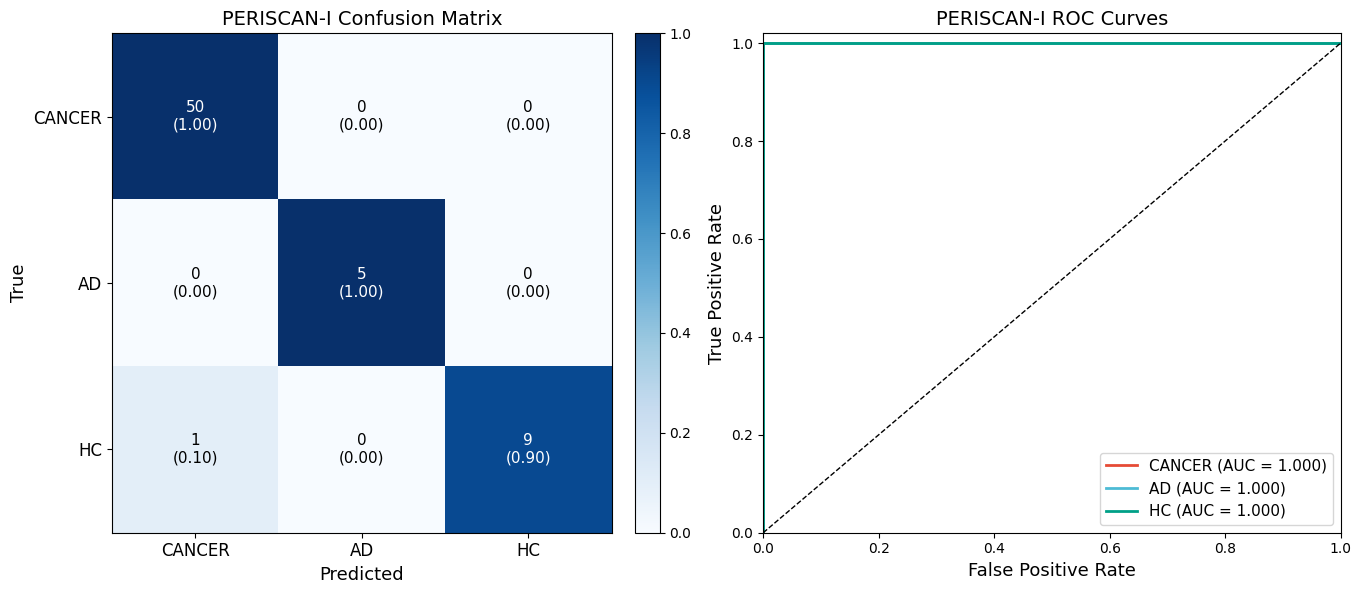

Saved to /results/periscan_evaluation.pdf


In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ============================================================
# 1. Confusion Matrix
# ============================================================
labels = ['CANCER', 'AD', 'HC']
cm = confusion_matrix(eval_df['true_label'], eval_df['prediction'], labels=labels)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

ax = axes[0]
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=12)
ax.set_yticklabels(labels, fontsize=12)
ax.set_xlabel('Predicted', fontsize=13)
ax.set_ylabel('True', fontsize=13)
ax.set_title('PERISCAN-I Confusion Matrix', fontsize=14)

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f'{cm[i,j]}\n({cm_norm[i,j]:.2f})',
                ha='center', va='center', fontsize=11,
                color='white' if cm_norm[i,j] > 0.5 else 'black')

# ============================================================
# 2. ROC curves (one-vs-rest)
# ============================================================
ax = axes[1]
colors = {'CANCER': '#E64B35', 'AD': '#4DBBD5', 'HC': '#00A087'}
prob_cols = {'CANCER': 'prob_CANCER', 'AD': 'prob_AD', 'HC': 'prob_HC'}

for label in labels:
    y_true_bin = (eval_df['true_label'] == label).astype(int)
    y_score    = eval_df[prob_cols[label]]
    fpr, tpr, _ = roc_curve(y_true_bin, y_score)
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colors[label], lw=2,
            label=f'{label} (AUC = {roc_auc:.3f})')

ax.plot([0,1], [0,1], 'k--', lw=1)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('PERISCAN-I ROC Curves', fontsize=14)
ax.legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.savefig('/results/periscan_evaluation.pdf', bbox_inches='tight', dpi=300)
plt.show()
print("Saved to /results/periscan_evaluation.pdf")

In [10]:
#Inspect misclassified samples
wrong = eval_df[eval_df['true_label'] != eval_df['prediction']]
print(wrong[['true_label', 'prediction', 'prob_AD', 'prob_CANCER', 'prob_HC', 'confidence']])

          true_label prediction  prob_AD  prob_CANCER  prob_HC  confidence
sample_id                                                                 
2                 HC     CANCER    0.006       0.7144   0.2796      0.7144


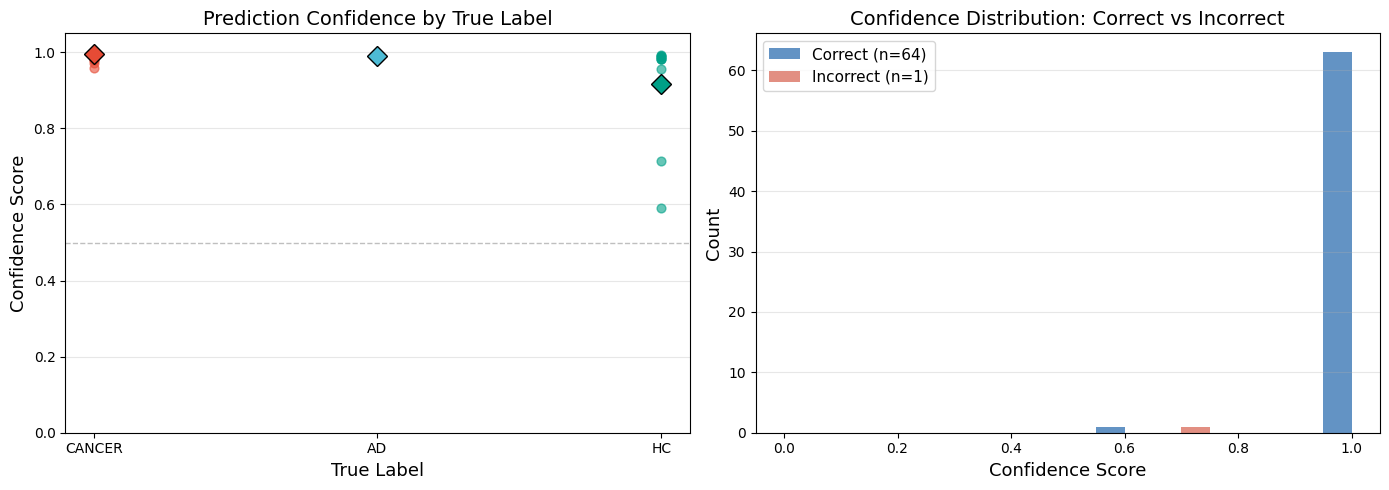

Saved to /results/periscan_confidence.pdf


In [11]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ============================================================
# 1. Confidence distribution by true label
# ============================================================
ax = axes[0]
colors = {'CANCER': '#E64B35', 'AD': '#4DBBD5', 'HC': '#00A087'}

for label in ['CANCER', 'AD', 'HC']:
    subset = eval_df[eval_df['true_label'] == label]['confidence']
    ax.scatter(
        [label] * len(subset), subset,
        color=colors[label], alpha=0.6, s=40, zorder=3
    )
    ax.plot(
        [label], [subset.mean()],
        marker='D', color=colors[label],
        markersize=10, markeredgecolor='black', zorder=4
    )

ax.set_ylim(0, 1.05)
ax.set_xlabel('True Label', fontsize=13)
ax.set_ylabel('Confidence Score', fontsize=13)
ax.set_title('Prediction Confidence by True Label', fontsize=14)
ax.axhline(0.5, color='gray', linestyle='--', lw=1, alpha=0.5)
ax.grid(axis='y', alpha=0.3)

# ============================================================
# 2. Confidence by correct vs incorrect
# ============================================================
ax = axes[1]
eval_df['correct'] = eval_df['true_label'] == eval_df['prediction']

for is_correct, label, color in [(True, 'Correct', '#2166AC'), (False, 'Incorrect', '#D6604D')]:
    subset = eval_df[eval_df['correct'] == is_correct]['confidence']
    ax.hist(subset, bins=20, range=(0, 1),
            color=color, alpha=0.7, label=f'{label} (n={len(subset)})')

ax.set_xlabel('Confidence Score', fontsize=13)
ax.set_ylabel('Count', fontsize=13)
ax.set_title('Confidence Distribution: Correct vs Incorrect', fontsize=14)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/results/periscan_confidence.pdf', bbox_inches='tight', dpi=300)
plt.show()
print("Saved to /results/periscan_confidence.pdf")